In [1]:
import sys
sys.path.append('../')
# from experiments import utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypolo2
import os
current_dir = os.getcwd()

# Average pm2.5 concentration for different team size

In [22]:
#区域平均污染物浓度
Setting = pypolo2.utilities.Config()
strategy_name = ["DualObjectScheduling",
                 "MaximumCoverageSpray",
                 "NonmyonicLatticeSpray",
                 "SATRACT",
                 "NoSpray",
                 ]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"]]
# seeds = [7,11,18,20,25,36,42,50]
seeds = [7,11,18,20,36,42,50]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]
total_step = 48
sche_step = 0
adaptive_step = 0
alpha = 1.6
strategy_pm25concentration = []
for strategy in strategy_name:
    if strategy == "NonmyonicLatticeSpray":
        sche_step = 12
        adaptive_step = 4
        seeds = seeds
    else:
        sche_step = 12
        adaptive_step = 3
        seeds = seeds
    variable_pm25concentration = []
    for i in range(5):
        comparing_variable = comparing_variables[0][i]
        team_size = team_sizes[i]
        sourcenum = 2
        seed_pm25concentration = []
        for seed in seeds:
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_pm25concentration = []
            for j in range(total_step):
                if j > 24:
                    pm25concentration = np.mean(data['truth_env'][j])
                    time_pm25concentration.append(pm25concentration)
            seed_pm25concentration.append(np.mean(time_pm25concentration))
        variable_pm25concentration.append(np.mean(seed_pm25concentration))
    strategy_pm25concentration.append(variable_pm25concentration)
strategy_pm25concentration = np.array(strategy_pm25concentration)
strategy_pm25concentration[-1,:] = np.mean(strategy_pm25concentration[-1,:])
print(strategy_pm25concentration)


[[57.60784122 44.21862349 36.74888775 30.16072578 28.53973077]
 [59.97338681 46.79663972 42.47348287 34.48863049 32.13542517]
 [61.96795073 48.9574525  40.71334703 44.8568743  40.5481818 ]
 [55.66194417 48.48575176 43.95059356 37.19287206 32.29559603]
 [84.11500962 84.11500962 84.11500962 84.11500962 84.11500962]]


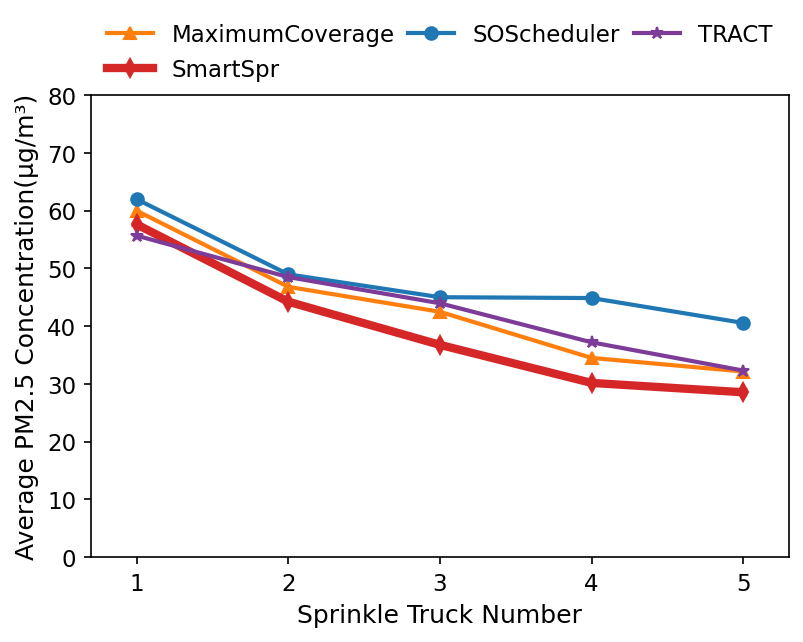

In [26]:
Time_deadline = 5
strategy_pm25concentration[2][2] = 45
xtitle = 'Sprinkle Truck Number'
ytitle = 'Average PM2.5 Concentration(μg/m³)'
filename = './outputs/png/line_AverageConcentration-teamsize12345-unknownenv.png'
colors_dict = ['#d62728', '#ff7f0e', '#1f77b4','#7D3C98','#008080','#808080']
ncol = 3
x_values = range(1, Time_deadline + 1)

plt.rcParams['legend.fontsize'] = 11  # 图例字体大小
plt.rcParams['axes.labelsize'] = 12  # 坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 11  # x轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 11  # y轴刻度字体大小

plt.figure(figsize =(6,4),dpi=150)

plt.plot(x_values, strategy_pm25concentration[1][0:Time_deadline], marker='^', color=colors_dict[1], linewidth=2, label='MaximumCoverage')
plt.plot(x_values, strategy_pm25concentration[0][0:Time_deadline], marker='d', color=colors_dict[0], linewidth=4, label='SmartSpr')
plt.plot(x_values, strategy_pm25concentration[2][0:Time_deadline], marker='o', color=colors_dict[2], linewidth=2, label='SOScheduler')
plt.plot(x_values, strategy_pm25concentration[3][0:Time_deadline], marker='*', color=colors_dict[3], linewidth=2, label='TRACT')


plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=ncol, frameon=False,columnspacing=0.6)

plt.xlim([1-0.3, Time_deadline+0.3])
plt.ylim([0, 80])

plt.savefig(filename,bbox_inches = 'tight')

# Average pm2.5 concentration for different source number

In [ ]:
# 区域pm2.5平均浓度变化
Setting = pypolo2.utilities.Config()
strategy_name = ["DualObjectScheduling",
                 "MaximumCoverageSpray",
                 "NonmyonicLatticeSpray",
                 "SATRACT",
                #  "NoSpray",
                 ]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"],
                       ["numsource_1","numsource_2","numsource_3","numsource_4","numsource_5"]]
# seeds1 = [7,11,18,20,25,36,42,50,60,72,80,85]
seeds = [7,11,18]
# seeds3 = [7,11,18,20,25,36,42,50,60,72,80,85]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]
strategy_meanpm = []
total_step = 48
sche_step = 0
adaptive_step = 0
alpha = 1.6
strategy_pm25concentration = []
for strategy in strategy_name:
    if strategy == "NonmyonicLatticeSpray":
        sche_step = 12
        adaptive_step = 4
        seeds = seeds
    else:
        sche_step = 12
        adaptive_step = 3
        seeds = seeds
    variable_pm25concentration = []
    for i in range(5):
        comparing_variable = comparing_variables[1][i]
        team_size = 4
        sourcenum = sourcenums[i]
        seed_pm25concentration = []
        for seed in seeds:
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            # pkldir = 'outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_pm25concentration = []
            for j in range(total_step):
                if j > 12:
                    pm25concentration = np.mean(data['truth_env'][j])
                    time_pm25concentration.append(pm25concentration)
            seed_pm25concentration.append(np.mean(time_pm25concentration))
        variable_pm25concentration.append(np.mean(seed_pm25concentration))
    strategy_pm25concentration.append(variable_pm25concentration)
strategy_pm25concentration = np.array(strategy_pm25concentration)
# strategy_pm25concentration[-1,:] = np.mean(strategy_pm25concentration[-1,:])
print(strategy_pm25concentration)

[[21.32199301 30.17268073 49.57778072 50.16812797 58.46372175]
 [18.46138806 32.31027413 52.05467709 57.94337655 65.58051776]
 [32.34260344 32.8921588  59.21772567 78.91067155 82.70345174]
 [28.67019919 37.24679514 52.79805651 57.46879044 63.47755142]]


(0.0, 100.0)

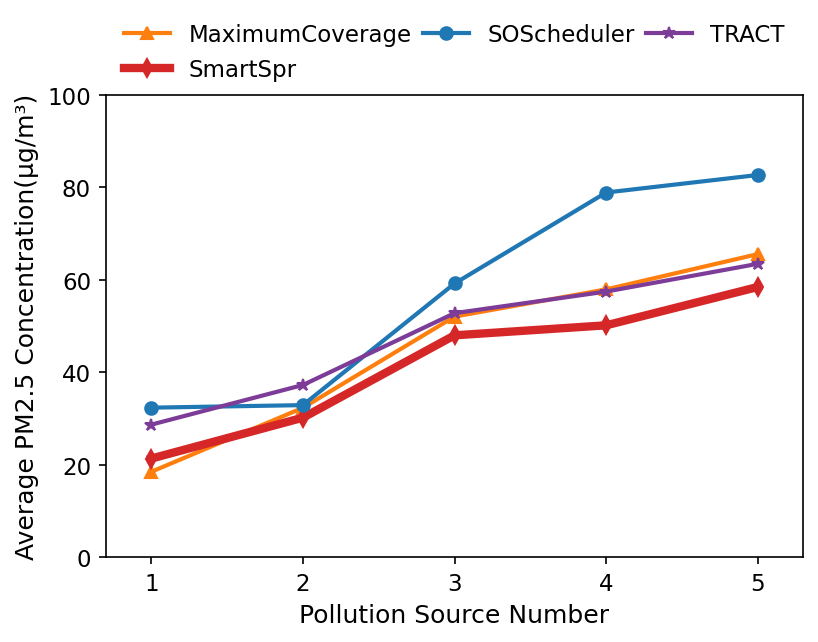

In [9]:
# strategy_pm25concentration[0][2] = 48
Time_deadline = 5
xtitle = 'Pollution Source Number'
ytitle = 'Average PM2.5 Concentration(μg/m³)'
filename = './outputs/png/line_AverageConcentration-source12345-unknownenv.png'
colors_dict = ['#d62728', '#ff7f0e', '#1f77b4','#7D3C98','#008080','#808080']
ncol = 3
x_values = range(1, Time_deadline + 1)

plt.rcParams['legend.fontsize'] = 11  # 图例字体大小
plt.rcParams['axes.labelsize'] = 12  # 坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 11  # x轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 11  # y轴刻度字体大小

plt.figure(figsize =(6,4),dpi=150)

# plt.plot(x_values, strategy_pm25concentration[5][0:Time_deadline], marker='s', color=colors_dict[5], linewidth=2, label='SmartSpr in Conjestion')
plt.plot(x_values, strategy_pm25concentration[1][0:Time_deadline], marker='^', color=colors_dict[1], linewidth=2, label='MaximumCoverage')
plt.plot(x_values, strategy_pm25concentration[0][0:Time_deadline], marker='d', color=colors_dict[0], linewidth=4, label='SmartSpr')
plt.plot(x_values, strategy_pm25concentration[2][0:Time_deadline], marker='o', color=colors_dict[2], linewidth=2, label='SOScheduler')
# plt.plot(x_values, strategy_pm25concentration[4][0:Time_deadline], marker='+', color=colors_dict[4], linewidth=2, label='TRACT')
plt.plot(x_values, strategy_pm25concentration[3][0:Time_deadline], marker='*', color=colors_dict[3], linewidth=2, label='TRACT')



plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=ncol, frameon=False, columnspacing=0.5)

plt.xlim([1-0.3, Time_deadline+0.3])
plt.ylim([0, 100])

# plt.savefig(filename,bbox_inches = 'tight')